# 🌡️ Day 18 - Temperature Prediction Across Multiple Weather Stations

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("BD_weather.csv")

In [3]:
# Create date column
df["date"] = pd.to_datetime(df[["Year", "Month", "Day"]])

In [4]:
# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

In [5]:
# Select features
FEATURE_COLS = ["Rainfall", "Sunshine", "Humidity", "Temperature"]
TARGET_COL = "Temperature"

data = df[["date"] + FEATURE_COLS].copy()

In [6]:
# Fill missing values
data[FEATURE_COLS] = data[FEATURE_COLS].ffill().bfill()

In [7]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data[FEATURE_COLS])
scaled_df = pd.DataFrame(scaled, columns=FEATURE_COLS)
scaled_df["date"] = data["date"].values

In [8]:
def make_sequences(values, lookback):
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i:i+lookback])
        y.append(values[i+lookback][FEATURE_COLS.index(TARGET_COL)])
    return np.array(X), np.array(y)

values = scaled_df[FEATURE_COLS].values
X, y = make_sequences(values, 14)

In [9]:
n_total = X.shape[0]
n_test = min(365, int(n_total * 0.2))
n_train = n_total - n_test

X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]

In [10]:
# Validation split
val_frac = 0.1
n_val = int(len(X_train) * val_frac)
X_val, y_val = X_train[-n_val:], y_train[-n_val:]
X_train, y_train = X_train[:-n_val], y_train[:-n_val]

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Shapes:
Train: (489114, 14, 4)
Val: (54346, 14, 4)
Test: (365, 14, 4)


In [16]:
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(14, len(FEATURE_COLS))),
    GRU(32),
    Dense(16, activation="relu"),
    Dense(1)
])


model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                         │ (None, 14, 64)              │          13,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_11 (GRU)                         │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,393 (91.38 KB)

 Trainable params: 23,393 (91.38 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
es = EarlyStopping(monitor="loss", patience=6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

Epoch 1/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 124s 30ms/step - loss: 0.0022 - mae: 0.0296 - val_loss: 0.0013 - val_mae: 0.0271
Epoch 2/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 116s 30ms/step - loss: 0.0014 - mae: 0.0275 - val_loss: 0.0013 - val_mae: 0.0266
Epoch 3/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 120s 31ms/step - loss: 0.0014 - mae: 0.0274 - val_loss: 0.0013 - val_mae: 0.0271
Epoch 4/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 146s 32ms/step - loss: 0.0014 - mae: 0.0273 - val_loss: 0.0013 - val_mae: 0.0284
Epoch 5/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 148s 34ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0013 - val_mae: 0.0271
Epoch 6/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 125s 33ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0013 - val_mae: 0.0272
Epoch 7/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 125s 33ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0012 - val_mae: 0.0267
Epoch 8/30
3822/3822 ━━━━━━━━━━━━━━━━━━━━ 144s 33ms/step - loss: 0.0013 - mae: 0.0271 - val_loss: 0.0014 - val_mae: 0.0287
Epoch 9/30
3822/

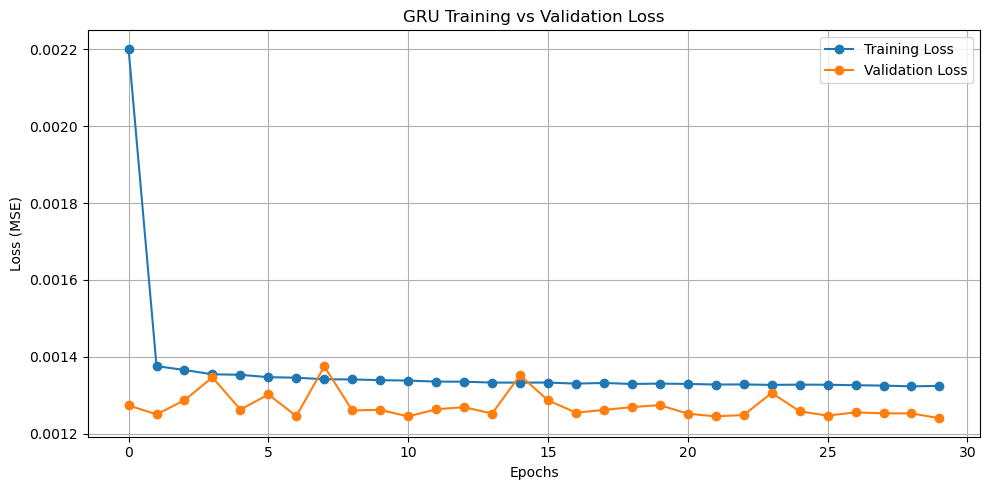

In [18]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss", marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", marker='o')

plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

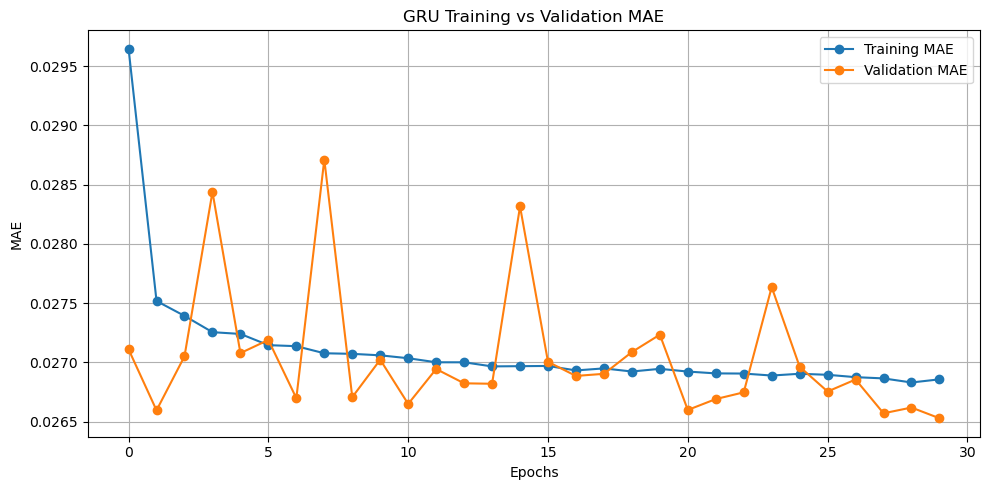

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history.history["mae"], label="Training MAE", marker='o')
plt.plot(history.history["val_mae"], label="Validation MAE", marker='o')

plt.title("GRU Training vs Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
pred_scaled = model.predict(X_test).flatten()

# invert scaling
def invert_target(scaled_array):
    dummy = np.zeros((len(scaled_array), len(FEATURE_COLS)))
    col_idx = FEATURE_COLS.index(TARGET_COL)
    dummy[:, col_idx] = scaled_array
    inv = scaler.inverse_transform(dummy)[:, col_idx]
    return inv

y_test_inv = invert_target(y_test)
pred_inv = invert_target(pred_scaled)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step 


In [21]:
mae = mean_absolute_error(y_test_inv, pred_inv)
rmse = mean_squared_error(y_test_inv, pred_inv)

print("Final Results:")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")

Final Results:
MAE  = 0.937
RMSE = 1.549


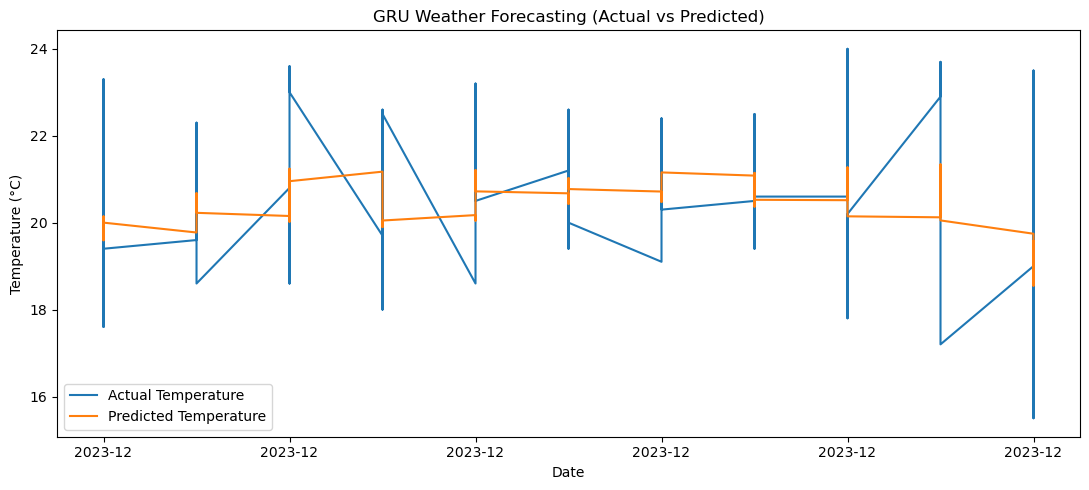

In [22]:
dates = data["date"].values[7 + n_train : 7 + n_train + len(y_test)]

plt.figure(figsize=(11,5))
plt.plot(dates, y_test_inv, label="Actual Temperature")
plt.plot(dates, pred_inv, label="Predicted Temperature")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("GRU Weather Forecasting (Actual vs Predicted)")
plt.legend()
plt.tight_layout()
plt.show()